In [1]:
import numpy as np
from pathlib import Path
import h5py
from idiff.bkg2d import gaussian
from plot import show_diffractograms
from dataset_enhancement import zero_spatial_edges
from data import rescale
from concurrent.futures import ThreadPoolExecutor, as_completed

result_dir = Path("dataset1.1/")
result_dir.mkdir(exist_ok=True)
split_name = "train"
result_path = result_dir / f"{split_name}_target.h5"

In [2]:
dataset = h5py.File(f"dataset1.1/{split_name}.h5", 'r')

In [3]:
skip_rest = False
save_data = True
scale_factor = 4

In [4]:
# Create file
if save_data:
    with h5py.File(result_path, 'w') as f:
        pass

def save_dataset(n, d):
    if not save_data:
        return
    
    with h5py.File(result_path, 'r+') as f:
        chunk_shape = (1, *d.shape[1:])
        f.create_dataset(
                n, 
                data=d,  
                compression="lzf", 
                chunks=chunk_shape,
                shuffle=True 
            )

In [5]:
def enhance_fn_mc(dataset, sigma, thr, area_size, show_n=0, skip_rest=False):
    def enhance_single(img):
        """Process a single image."""
        img_rescaled = rescale(img, scale_factor)
        img_rescaled = img_rescaled.astype(np.float32) # This improves processing speed
        img_processed = gaussian(img_rescaled, thr, area_size, sigma)
        img_processed = zero_spatial_edges(img_processed, border_width=5)
        return img_processed.astype(np.float16)

    imgs = [None] * len(dataset)

    with ThreadPoolExecutor() as executor:
        futures = {executor.submit(enhance_single, dataset[i]): i 
                   for i in range(len(dataset)) if not skip_rest or i < show_n}
        
        for future in as_completed(futures):
            i = futures[future]
            imgs[i] = future.result()
        
    for i in range(show_n):
        show_diffractograms({
            "Before": dataset[i],
            "After": imgs[i]
        }, title=i)

    if not skip_rest:
        print(len(imgs))
        return np.stack(imgs)

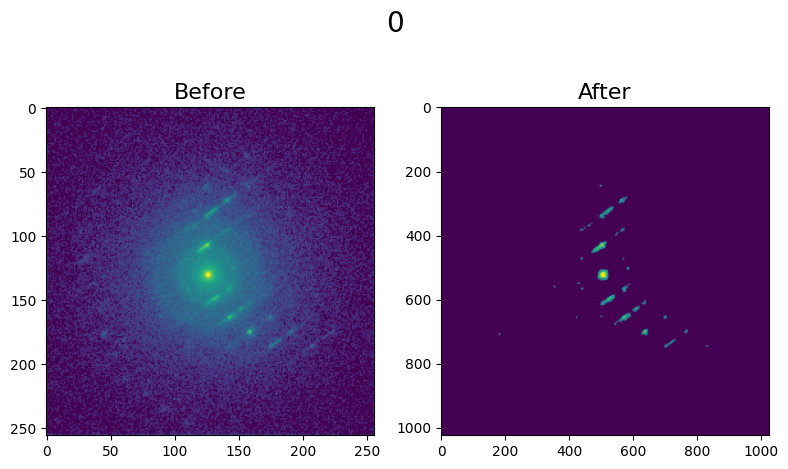

630
au: (630, 1024, 1024)


In [6]:
name = "au"
result = enhance_fn_mc(dataset[name], sigma=30, thr=10, area_size=30, show_n=1, skip_rest=skip_rest)
save_dataset(name, result)
print(f"{name}: {result.shape}")
result = None # Free memory

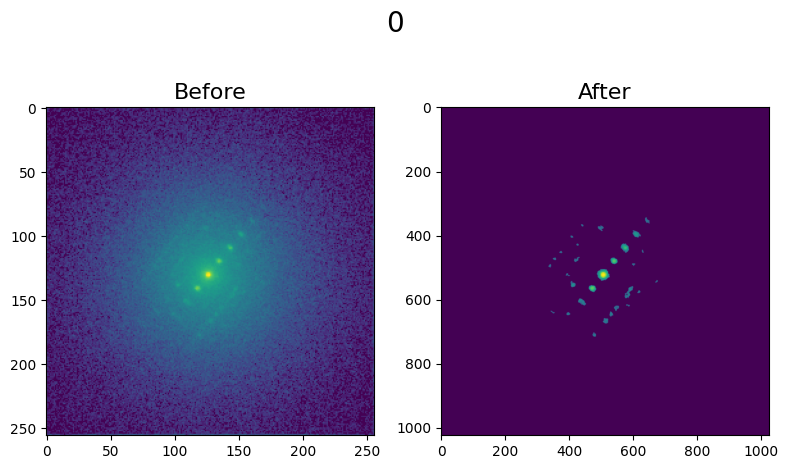

5600
tbf3: (5600, 1024, 1024)


In [7]:
name = "tbf3"
result = enhance_fn_mc(dataset[name], sigma=30, thr=10, area_size=40, show_n=1, skip_rest=skip_rest)
save_dataset(name, result)
print(f"{name}: {result.shape}")
result = None # Free memory

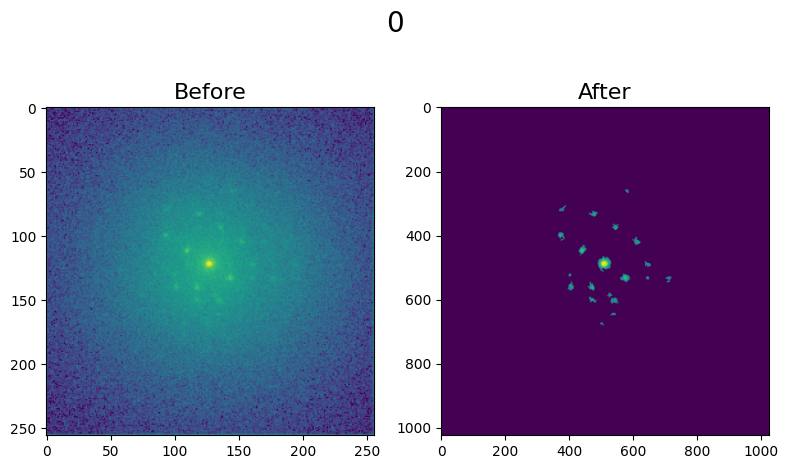

5040
feo: (5040, 1024, 1024)


In [8]:
name = "feo"
result = enhance_fn_mc(dataset[name], sigma=30, thr=10, area_size=70, show_n=1, skip_rest=skip_rest)
save_dataset(name, result)
print(f"{name}: {result.shape}")
result = None # Free memory

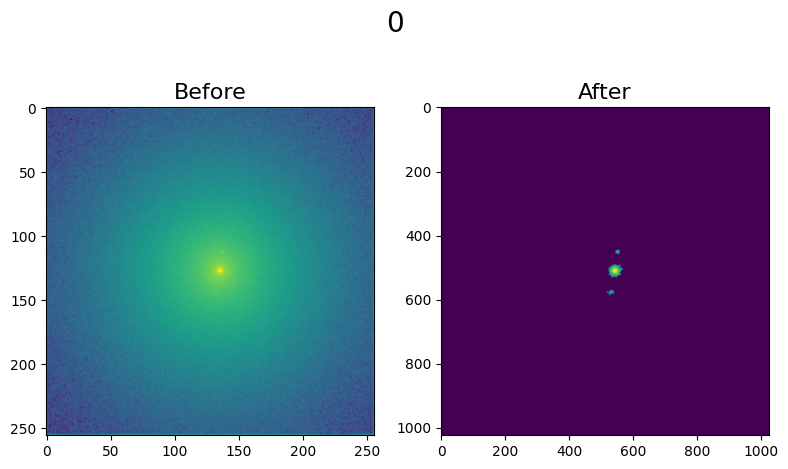

4760
laf3: (4760, 1024, 1024)


In [9]:
name = "laf3"
result = enhance_fn_mc(dataset[name], sigma=20, thr=25, area_size=70, show_n=1, skip_rest=skip_rest)
save_dataset(name, result)
print(f"{name}: {result.shape}")
result = None # Free memory

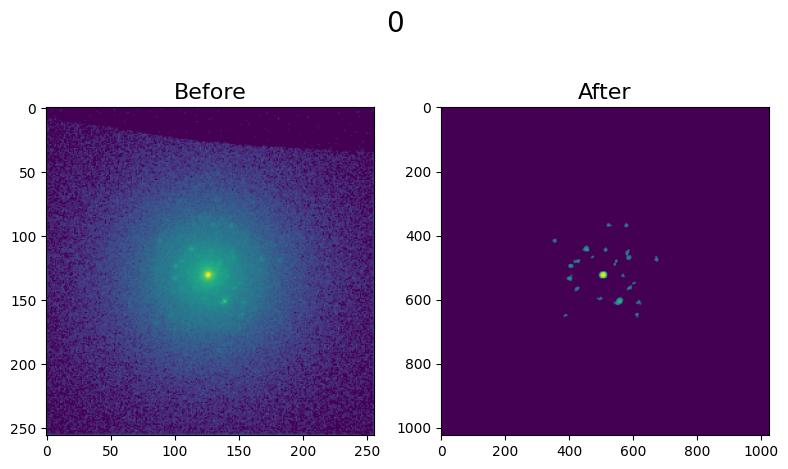

5600
gdf3: (5600, 1024, 1024)


In [10]:
name = "gdf3"
result = enhance_fn_mc(dataset[name], sigma=20, thr=11, area_size=60, show_n=1, skip_rest=skip_rest)
save_dataset(name, result)
print(f"{name}: {result.shape}")
result = None # Free memory